In [1]:
import json

In [2]:
with open('eval_check_items_filtered.txt', 'r') as file:
    filt_items = file.read()
filt_items_lines = [line.strip() for line in filt_items.splitlines() if line.strip()]
print(len(filt_items_lines))
filt_items_lines[:3]

45


['000000003156_person_toilet.png',
 '000000006894_elephant_person.png',
 '000000006894_person_elephant.png']

In [3]:
import json

filt_specs = []
for item in filt_items_lines:
    item = item.replace(".png", "")
    coco, ref, qry = item.split("_")
    filt_specs.append((coco, ref.lower(), qry.lower()))

question_ids = []

with open("questions/direct_pose.jsonl", "r") as f:
    for line in f:
        obj = json.loads(line)
        img_name = obj.get("image", "")
        text = obj.get("text", "").lower()
        qid = obj.get("question_id")

        # Extract coco id from image filename
        coco_id = img_name.split(".")[0]

        # Check against all filtered (coco, ref, query) triplets
        for cid, ref, qry in filt_specs:
            if cid == coco_id and ref in text and qry in text:
                question_ids.append(qid)
                break  # stop checking other filters for this entry

print("Matched question_ids:", question_ids)

Matched question_ids: [0, 1, 2, 4, 5, 18, 21, 31, 34, 38, 44, 45, 47, 48, 59, 63, 72, 91, 93, 96, 120, 124, 136, 137, 142, 145, 146, 148, 150, 151, 172, 189, 198, 245, 255, 261, 277, 284, 345, 347, 349, 377, 439, 464, 465, 477, 486, 502]


In [4]:
with open('answers.jsonl', 'r') as file:
    answers = [json.loads(line) for line in file]

print(answers[:10])

[{'question_id': 0, 'reference': 'person', 'query': 'toilet', 'text': 'left', 'azimuth': 252.0}, {'question_id': 1, 'reference': 'person', 'query': 'elephant', 'text': 'right', 'azimuth': 180.0}, {'question_id': 2, 'reference': 'elephant', 'query': 'person', 'text': 'left', 'azimuth': 144.0}, {'question_id': 3, 'reference': 'person', 'query': 'umbrella', 'text': 'left', 'azimuth': 180.0}, {'question_id': 4, 'reference': 'person', 'query': 'tv', 'text': 'left', 'azimuth': 252.0}, {'question_id': 5, 'reference': 'person', 'query': 'keyboard', 'text': 'left', 'azimuth': 252.0}, {'question_id': 7, 'reference': 'person', 'query': 'pizza', 'text': 'left', 'azimuth': 72.0}, {'question_id': 8, 'reference': 'person', 'query': 'dining table', 'text': 'left', 'azimuth': 144.0}, {'question_id': 9, 'reference': 'person', 'query': 'laptop', 'text': 'right', 'azimuth': 144.0}, {'question_id': 10, 'reference': 'person', 'query': 'cell phone', 'text': 'right', 'azimuth': 0.0}]


In [5]:
left_right_answers = [ans['text'] for ans in answers if ans['question_id'] in question_ids]
print(left_right_answers[:10])

['left', 'right', 'left', 'left', 'left', 'right', 'left', 'left', 'right', 'left']


In [6]:
angles = [ans['azimuth'] for ans in answers if ans['question_id'] in question_ids]
# 0 is aligned, 1 unaligned, 2 is perpendicular
alignment = [0 if angle in [0, 36, 72, 288, 324] else (1 if angle in [108, 144, 180, 216, 252] else 2) for angle in angles]

In [7]:
set(angles), set(alignment)

({0.0, 36.0, 108.0, 144.0, 180.0, 216.0, 252.0, 288.0, 324.0}, {0, 1})

### Base results

In [8]:
with open('answers/answers_base.jsonl', 'r') as file:
    base_answers = [json.loads(line) for line in file]
print(base_answers[:10])

[{'question_id': 0, 'prompt': "A person and a toilet are shown in the image. Which side of the person is the toilet on from the person's perspective?", 'text': "From the person's perspective, the toilet is on their right side.", 'answer_id': 'f3MKDWhn7LmGsNApwDvNzV', 'model_id': 'llava-v1.5-13b', 'metadata': {}}, {'question_id': 1, 'prompt': "A person and a elephant are shown in the image. Which side of the person is the elephant on from the person's perspective?", 'text': "The elephant is on the left side of the person from the person's perspective.", 'answer_id': 'H4W2omHscFNCPkNrTDmDJW', 'model_id': 'llava-v1.5-13b', 'metadata': {}}, {'question_id': 2, 'prompt': "A elephant and a person are shown in the image. Which side of the elephant is the person on from the elephant's perspective?", 'text': "The person is on the right side of the elephant from the elephant's perspective.", 'answer_id': 'dCM5qNfSFrAZLUpWuPKs2K', 'model_id': 'llava-v1.5-13b', 'metadata': {}}, {'question_id': 3, '

In [9]:
base_responses = [ans['text'] for ans in base_answers if ans['question_id'] in question_ids]
print(base_responses[:10])

["From the person's perspective, the toilet is on their right side.", "The elephant is on the left side of the person from the person's perspective.", "The person is on the right side of the elephant from the elephant's perspective.", "The tv is on the right side of the person from the person's perspective.", "From the person's perspective, the keyboard is on the right side of the person.", "From the person's perspective, the bowl is on their left side.", 'The skateboard is on the left side of the person from their perspective.', "From the person's perspective, the laptop is on the left side.", "From the person's perspective, the handbag is on their left side.", "From the person's perspective, the skis are on their right side."]


In [10]:
base_answers_clean = []

for ans in base_responses:
    if 'left' in ans.lower():
        base_answers_clean.append('left')
    elif 'right' in ans.lower():
        base_answers_clean.append('right')
    else:
        base_answers_clean.append('unknown')
print(base_answers_clean[:10])

['right', 'left', 'right', 'right', 'right', 'left', 'left', 'left', 'left', 'right']


In [41]:
base_correct = [base == lr for base, lr in zip(base_answers_clean, left_right_answers)]
base_acc = sum(base_correct) / len(base_correct)
print(f"Base accuracy: {base_acc:.4f}")

Base accuracy: 0.3125


In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [43]:
def plot_by_alignment(data, alignment=alignment):

    alignment = np.array(alignment)
    data = np.array(data)

    aligned_acc = np.mean(data[alignment == 0])
    unaligned_acc = np.mean(data[alignment == 1])
    #perpendicular_acc = np.mean(data[alignment == 2])
    print(aligned_acc, unaligned_acc)
    aligned_sem = np.std(data[alignment == 0]) / np.sqrt(len(data[alignment == 0]))
    unaligned_sem = np.std(data[alignment == 1]) / np.sqrt(len(data[alignment == 1]))
    #perpendicular_sem = np.std(data[alignment == 2]) / np.sqrt(len(data[alignment == 2]))

    plt.bar(['aligned', 'unaligned'], [aligned_acc, unaligned_acc], yerr=[aligned_sem, unaligned_sem],
            align='center', alpha=0.7, ecolor='black', capsize=10)
    plt.ylim(0, 1)
    plt.ylabel('accuracy')
    plt.title('Accuracy by Alignment')
    plt.show()

    return aligned_acc, unaligned_acc

0.8333333333333334 0.1388888888888889


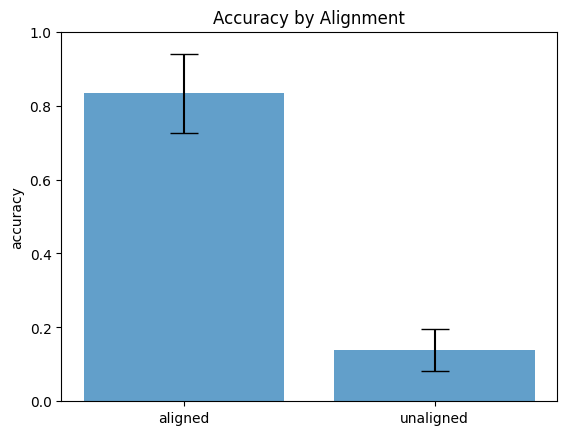

In [44]:
base_aligned_acc, base_unaligned_acc = plot_by_alignment(base_correct)

### Text results

In [45]:
with open('answers/answers_vit_text.jsonl', 'r') as file:
    text_answers = [json.loads(line) for line in file]
print(text_answers[:10])

[{'question_id': 0, 'prompt': "A person and a toilet are shown in the image. Which side of the person is the toilet on from the person's perspective?", 'text': 'left', 'answer_id': 'f8sh9BdfqLxu6fmJ7pRdYP', 'model_id': 'train_text_annealing-llava-v1.5-13b-task-lora-ViT', 'metadata': {}}, {'question_id': 1, 'prompt': "A person and a elephant are shown in the image. Which side of the person is the elephant on from the person's perspective?", 'text': 'right', 'answer_id': 'CmGBg9WKWjPxU9hUyengkC', 'model_id': 'train_text_annealing-llava-v1.5-13b-task-lora-ViT', 'metadata': {}}, {'question_id': 2, 'prompt': "A elephant and a person are shown in the image. Which side of the elephant is the person on from the elephant's perspective?", 'text': 'right', 'answer_id': '7488qy5GuijRaEkqZ6qwxb', 'model_id': 'train_text_annealing-llava-v1.5-13b-task-lora-ViT', 'metadata': {}}, {'question_id': 3, 'prompt': "A person and a umbrella are shown in the image. Which side of the person is the umbrella on f

In [46]:
text_responses = [ans['text'] for ans in text_answers if ans['question_id'] in question_ids]
print(text_responses[:10])

['left', 'right', 'right', 'left', 'left', 'right', 'left', 'left', 'right', 'left']


In [47]:
text_correct = [text == lr for text, lr in zip(text_responses, left_right_answers)]
text_acc = sum(text_correct) / len(text_correct)
print(f"Text accuracy: {text_acc:.4f}")

Text accuracy: 0.8125


0.75 0.8333333333333334


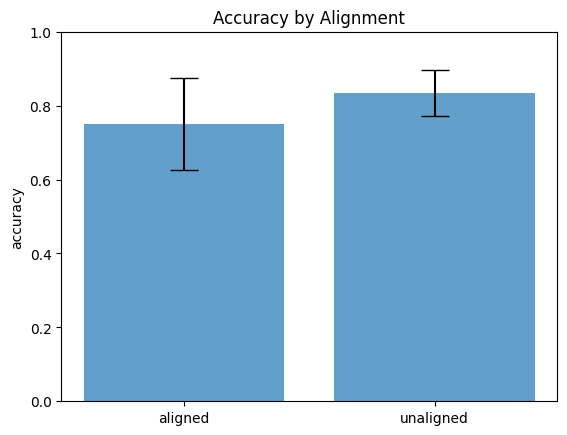

In [48]:
text_aligned_acc, text_unaligned_acc = plot_by_alignment(text_correct)

##### text CoT

In [49]:
with open('answers/answers_vit_text_CoT.jsonl', 'r') as file:
    text_cot_answers = [json.loads(line) for line in file]
print(text_cot_answers[:10])

[{'question_id': 0, 'prompt': "A person and a toilet are shown in the image. Which side of the person is the toilet on from the person's perspective?\nTo answer this question, let's think through it step by step, and we know the image is 336 x 336. First, what is the toilet's position relative to the person from the viewer's frame?\nSecond, what is the person's pose in token form?\nThird, from the pose, what is the person's orientation bin and do they face toward or away from the viewer?\nFourth, mentally rotate the viewer's frame to align with the person's orientation, what side of the person did the toilet end up on?\n", 'text': "The toilet is right of the person from the viewer's frame. The person's pose is 159.0 101.0 0.9 99.0 90.0 0.8 87.0 207.0 0.7 39.0 207.0 0.6 3 3. Since 3 lies in the 135-180 bin, the person is unaligned. After performing a mental rotation of 135-180 degrees, the toilet is now to the left. Therefore, the toilet is to the left from the perspective of the person

In [50]:
text_cot_responses = [ans['text'].split('is to the ')[1].split('from the perspective of the ')[0].strip() for ans in text_cot_answers if ans['question_id'] in question_ids]
print(text_cot_responses[:10])

['left', 'right', 'left', 'left', 'left', 'right', 'left', 'left', 'right', 'left']


In [51]:
text_cot_correct = [text == lr for text, lr in zip(text_cot_responses, left_right_answers)]
text_cot_acc = sum(text_cot_correct) / len(text_cot_correct)
print(f"Text CoT accuracy: {text_cot_acc:.4f}")

Text CoT accuracy: 0.8750


0.6666666666666666 0.9444444444444444


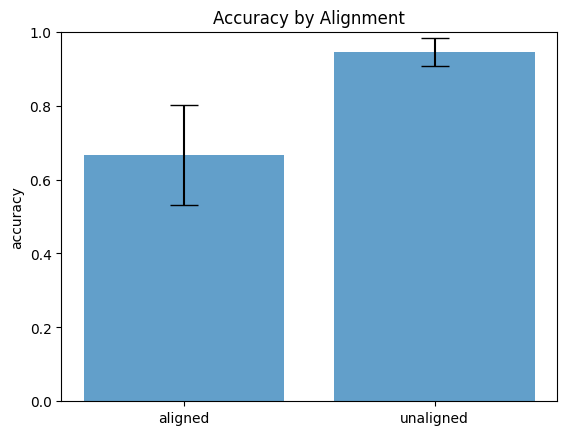

In [52]:
text_cot_aligned_acc, text_cot_unaligned_acc = plot_by_alignment(text_cot_correct)

### COCO results

In [53]:
with open('answers/answers_coco.jsonl', 'r') as file:
    coco_answers = [json.loads(line) for line in file]
print(coco_answers[:10])

[{'question_id': 0, 'prompt': "A person and a toilet are shown in the image. Which side of the person is the toilet on from the person's perspective?", 'text': 'right', 'answer_id': 'oCdYj6Qd2BUSA5jYNVf7Y6', 'model_id': 'train_perspective_annealing-llava-v1.5-13b-task-lora', 'metadata': {}}, {'question_id': 1, 'prompt': "A person and a elephant are shown in the image. Which side of the person is the elephant on from the person's perspective?", 'text': 'right', 'answer_id': 'Yi4rXNcQirbLQBKuKyN4fq', 'model_id': 'train_perspective_annealing-llava-v1.5-13b-task-lora', 'metadata': {}}, {'question_id': 2, 'prompt': "A elephant and a person are shown in the image. Which side of the elephant is the person on from the elephant's perspective?", 'text': 'right', 'answer_id': 'hKphGutBZJwGwvRqa9mnFQ', 'model_id': 'train_perspective_annealing-llava-v1.5-13b-task-lora', 'metadata': {}}, {'question_id': 3, 'prompt': "A person and a umbrella are shown in the image. Which side of the person is the umb

In [54]:
coco_responses = [ans['text'] for ans in coco_answers if ans['question_id'] in question_ids]
print(coco_responses[:10])

['right', 'right', 'right', 'left', 'left', 'right', 'left', 'left', 'right', 'left']


In [55]:
coco_correct = [coco == lr for coco, lr in zip(coco_responses, left_right_answers)]
coco_acc = sum(coco_correct) / len(coco_correct)
print(f"Coco accuracy: {coco_acc:.4f}")

Coco accuracy: 0.7500


0.5833333333333334 0.8055555555555556


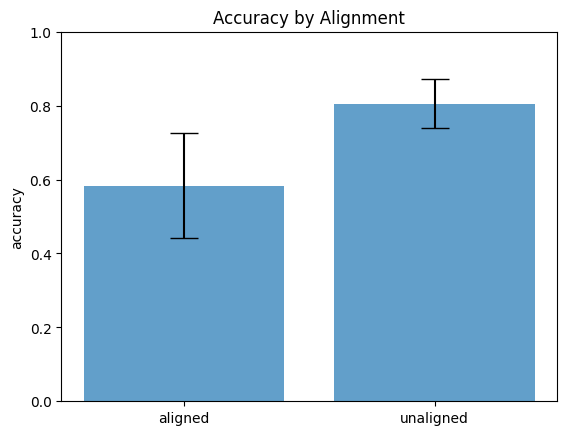

In [56]:
coco_aligned_acc, coco_unaligned_acc = plot_by_alignment(coco_correct)

#### cot

In [57]:
with open('answers/answers_coco_CoT.jsonl', 'r') as file:
    coco_cot_answers = [json.loads(line) for line in file]
print(coco_cot_answers[0]['text'])

The toilet is right of the person from the viewer's frame. The person's pose is  <POSE_START> <SHOULDER_L> <X_171> <Y_86> <SHOULDER_R> <X_100> <Y_91> <HIP_L> <X_110> <Y_196> <HIP_R> <X_44> <Y_193> <ORIENT_START> <YAW_3> <TORSO_W_3> <ORIENT_END> <POSE_END> . Since  <YAW_3> lies in the 135-180 bin, the person is unaligned. After performing a mental rotation of 135-180 degrees, the toilet is now to the left. Therefore, the toilet is to the left from the perspective of the person.


In [28]:
coco_cot_responses = [ans['text'].split('is to the ')[1].split('from the perspective of the ')[0].strip() if 'is to the ' in ans['text'] and 'from the perspective of the ' in ans['text'] else None for ans in coco_cot_answers if ans['question_id'] in question_ids]
print(coco_cot_responses[:10])

['left', 'right', 'left', 'left', 'left', 'right', 'left', 'right', 'right', 'left']


In [58]:
coco_cot_correct = [coco_cot == lr for coco_cot, lr in zip(coco_cot_responses, left_right_answers)]
coco_cot_acc = sum(coco_cot_correct) / len(coco_cot_correct)
print(f"Coco CoT accuracy: {coco_cot_acc:.4f}")

Coco CoT accuracy: 0.8333


0.5833333333333334 0.9166666666666666


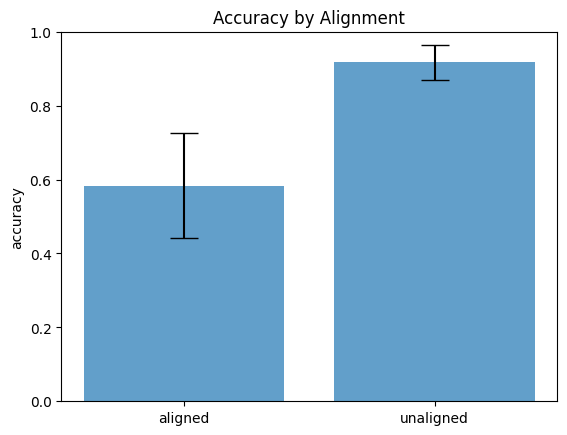

In [59]:
coco_cot_aligned_acc, coco_cot_unaligned_acc = plot_by_alignment(coco_cot_correct)

### ViT results

In [60]:
with open('answers/answers_vit.jsonl', 'r') as file:
    vit_answers = [json.loads(line) for line in file]
print(vit_answers[:10])

[{'question_id': 0, 'prompt': "A person and a toilet are shown in the image. Which side of the person is the toilet on from the person's perspective?", 'text': 'left', 'answer_id': 'g2dsbi3q8wec2yV8sWE4KP', 'model_id': 'train_perspective_annealing-llava-v1.5-13b-task-lora-ViT', 'metadata': {}}, {'question_id': 1, 'prompt': "A person and a elephant are shown in the image. Which side of the person is the elephant on from the person's perspective?", 'text': 'right', 'answer_id': 'ib9dn23EgzKtfd6kJYo85k', 'model_id': 'train_perspective_annealing-llava-v1.5-13b-task-lora-ViT', 'metadata': {}}, {'question_id': 2, 'prompt': "A elephant and a person are shown in the image. Which side of the elephant is the person on from the elephant's perspective?", 'text': 'right', 'answer_id': 'RxwARyoSF36YF3zn7sGbfr', 'model_id': 'train_perspective_annealing-llava-v1.5-13b-task-lora-ViT', 'metadata': {}}, {'question_id': 3, 'prompt': "A person and a umbrella are shown in the image. Which side of the person

In [61]:
vit_responses = [ans['text'] for ans in vit_answers if ans['question_id'] in question_ids]
print(vit_responses[:10])

['left', 'right', 'right', 'left', 'left', 'right', 'left', 'left', 'right', 'left']


In [62]:
vit_correct = [vit == lr for vit, lr in zip(vit_responses, left_right_answers)]
vit_acc = sum(vit_correct) / len(vit_correct)
print(f"ViT accuracy: {vit_acc:.4f}")

ViT accuracy: 0.7917


0.5833333333333334 0.8611111111111112


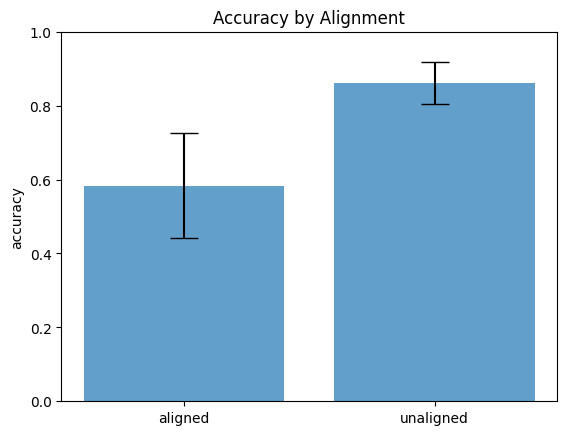

In [63]:
vit_aligned_acc, vit_unaligned_acc = plot_by_alignment(vit_correct)

#### cot

In [64]:
with open('answers/answers_vit_CoT.jsonl', 'r') as file:
    vit_cot_answers = [json.loads(line) for line in file]
print(vit_cot_answers[0]['text'])

The toilet is right of the person from the viewer's frame. The person's pose is  <POSE_START> <SHOULDER_L> <X_160> <Y_97> <TORSO_W_0> <SHOULDER_R> <X_109> <Y_92> <TORSO_W_0> <HIP_L> <X_111> <Y_200> <YAW_7> <HIP_R> <X_36> <Y_194> <YAW_7> <ORIENT_START> <CONF_1> <CONF_9> <ORIENT_END> <POSE_END> . Since YAW_2 lies in the 90-135 bin, the person is unaligned. After performing a mental rotation of 90-135 degrees, the toilet is now to the left. Therefore, the toilet is to the left from the perspective of the person.


In [65]:
vit_cot_responses = [ans['text'].split('is to the ')[1].split('from the perspective of the ')[0].strip() if 'is to the ' in ans['text'] and 'from the perspective of the ' in ans['text'] else None for ans in vit_cot_answers if ans['question_id'] in question_ids]
print(vit_cot_responses[:10])

['left', 'right', 'left', 'left', 'left', 'right', 'right', 'right', 'right', 'left']


In [68]:
vit_cot_correct = [vit == lr for vit, lr in zip(vit_cot_responses, left_right_answers)]
vit_cot_acc = sum(vit_cot_correct) / len(vit_cot_correct)
print(f"ViT CoT accuracy: {vit_cot_acc:.4f}")

ViT CoT accuracy: 0.7708


0.5833333333333334 0.8333333333333334


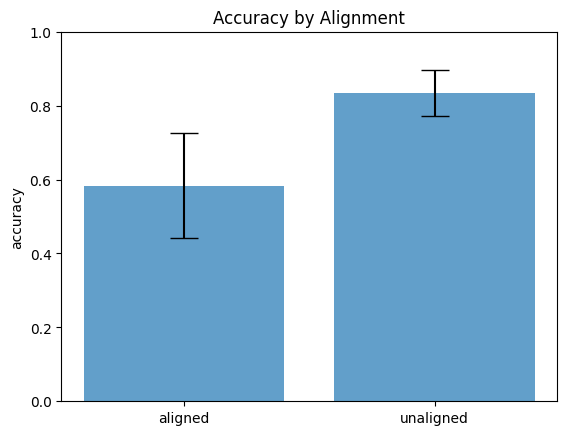

In [67]:
vit_cot_aligned_acc, vit_cot_unaligned_acc = plot_by_alignment(vit_cot_correct)

In [69]:
text_avg_acc = (text_acc + text_cot_acc) / 2
text_avg_aligned_acc = (text_aligned_acc + text_cot_aligned_acc) / 2
text_avg_unaligned_acc = (text_unaligned_acc + text_cot_unaligned_acc) / 2

coco_avg_acc = (coco_acc + coco_cot_acc) / 2
coco_avg_aligned_acc = (coco_aligned_acc + coco_cot_aligned_acc) / 2
coco_avg_unaligned_acc = (coco_unaligned_acc + coco_cot_unaligned_acc) / 2

vit_avg_acc = (vit_acc + vit_cot_acc) / 2
vit_avg_aligned_acc = (vit_aligned_acc + vit_cot_aligned_acc) / 2
vit_avg_unaligned_acc = (vit_unaligned_acc + vit_cot_unaligned_acc) / 2

In [72]:
print("base model")
print(f"Base accuracy: {base_acc:.4f}, aligned: {base_aligned_acc:.4f}, unaligned: {base_unaligned_acc:.4f}")
print("text model")
print(f"Text accuracy: {text_acc:.4f}, aligned: {text_aligned_acc:.4f}, unaligned: {text_unaligned_acc:.4f}")
print(f"Text CoT accuracy: {text_cot_acc:.4f}, aligned: {text_cot_aligned_acc:.4f}, unaligned: {text_cot_unaligned_acc:.4f}")
print(f"Average Text accuracy: {text_avg_acc:.4f}, aligned: {text_avg_aligned_acc:.4f}, unaligned: {text_avg_unaligned_acc:.4f}")
print("coco model")
print(f"Coco accuracy: {coco_acc:.4f}, aligned: {coco_aligned_acc:.4f}, unaligned: {coco_unaligned_acc:.4f}")
print(f"Coco CoT accuracy: {coco_cot_acc:.4f}, aligned: {coco_cot_aligned_acc:.4f}, unaligned: {coco_cot_unaligned_acc:.4f}")
print(f"Average Coco accuracy: {coco_avg_acc:.4f}, aligned: {coco_avg_aligned_acc:.4f}, unaligned: {coco_avg_unaligned_acc:.4f}")
print("vit model")
print(f"ViT accuracy: {vit_acc:.4f}, aligned: {vit_aligned_acc:.4f}, unaligned: {vit_unaligned_acc:.4f}")
print(f"ViT CoT accuracy: {vit_cot_acc:.4f}, aligned: {vit_cot_aligned_acc:.4f}, unaligned: {vit_cot_unaligned_acc:.4f}")
print(f"Average ViT accuracy: {vit_avg_acc:.4f}, aligned: {vit_avg_aligned_acc:.4f}, unaligned: {vit_avg_unaligned_acc:.4f}")

base model
Base accuracy: 0.3125, aligned: 0.8333, unaligned: 0.1389
text model
Text accuracy: 0.8125, aligned: 0.7500, unaligned: 0.8333
Text CoT accuracy: 0.8750, aligned: 0.6667, unaligned: 0.9444
Average Text accuracy: 0.8438, aligned: 0.7083, unaligned: 0.8889
coco model
Coco accuracy: 0.7500, aligned: 0.5833, unaligned: 0.8056
Coco CoT accuracy: 0.8333, aligned: 0.5833, unaligned: 0.9167
Average Coco accuracy: 0.7917, aligned: 0.5833, unaligned: 0.8611
vit model
ViT accuracy: 0.7917, aligned: 0.5833, unaligned: 0.8611
ViT CoT accuracy: 0.7708, aligned: 0.5833, unaligned: 0.8333
Average ViT accuracy: 0.7812, aligned: 0.5833, unaligned: 0.8472


In [74]:
coco_avg_acc - base_acc, coco_avg_unaligned_acc - base_unaligned_acc

(0.47916666666666674, 0.7222222222222223)